In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings('ignore')

In [41]:
df = pd.read_excel('Flight_dataset[4039].xlsx')

In [42]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5953.0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,NaN,1.0,5956.0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1.0,5955.0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0


In [43]:
df.shape

(300153, 12)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300141 non-null  float64
 10  days_left         300148 non-null  float64
 11  price             300148 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 27.5+ MB


In [45]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300141.00000,300148.000000,300148.000000
mean,150076.000000,12.22118,26.005154,20889.757586
std,86646.852011,7.19199,13.560757,22697.934166
min,0.000000,0.83000,1.000000,1105.000000
25%,75038.000000,6.83000,15.000000,4783.000000
50%,150076.000000,11.25000,26.000000,7425.000000
75%,225114.000000,16.17000,38.000000,42521.000000
max,300152.000000,49.83000,49.000000,123071.000000


In [46]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,12


In [47]:
df.dropna(inplace=True)

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.drop_duplicates(inplace=True)

In [50]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [51]:
df.shape

(300133, 11)

In [52]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5953.0
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1.0,5955.0
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1.0,5955.0


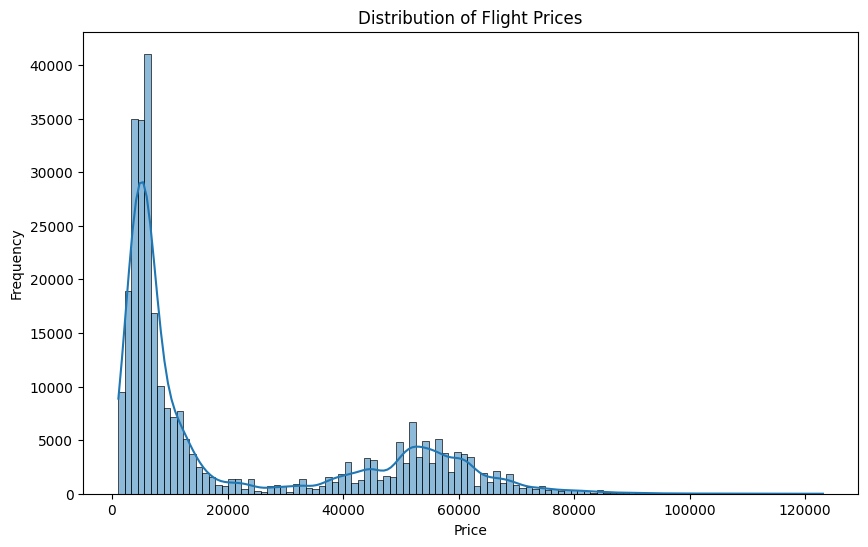

In [53]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

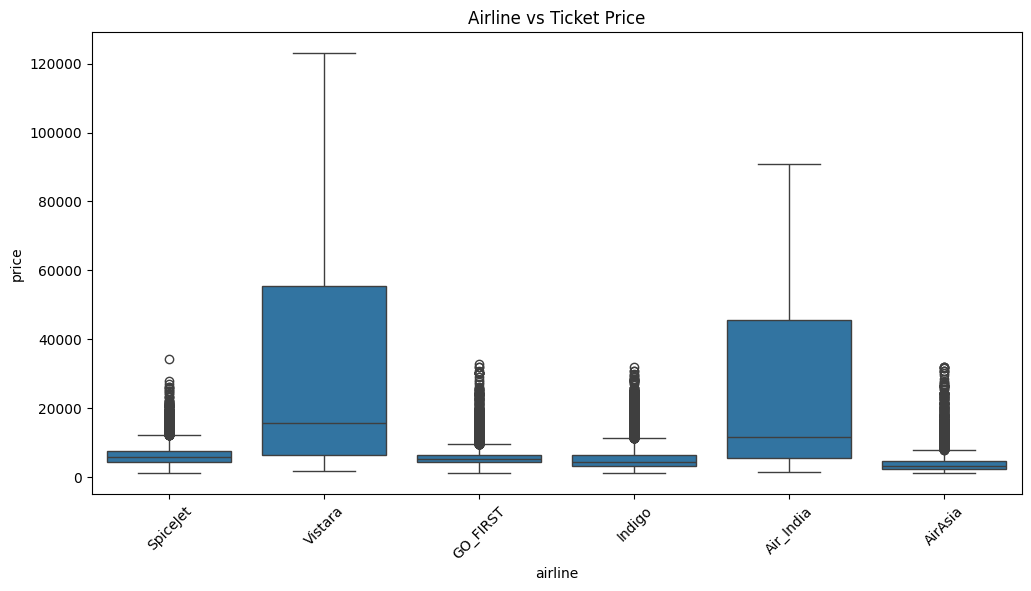

In [54]:
plt.figure(figsize=(12,6))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Airline vs Ticket Price')
plt.show()

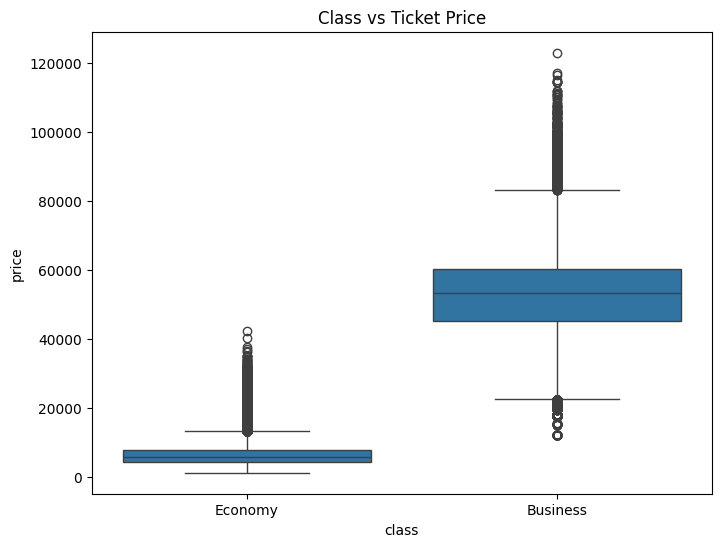

In [55]:
plt.figure(figsize=(8,6))
sns.boxplot(x='class', y='price', data=df)
plt.title('Class vs Ticket Price')
plt.show()

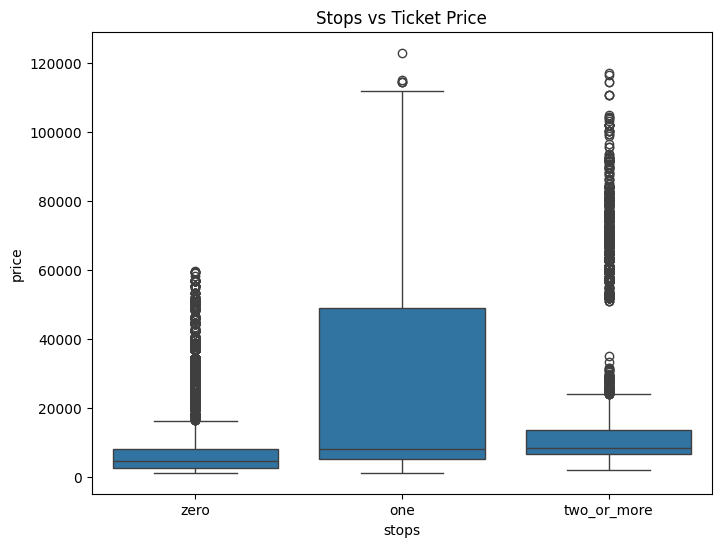

In [56]:
plt.figure(figsize=(8,6))
sns.boxplot(x='stops', y='price', data=df)
plt.title('Stops vs Ticket Price')
plt.show()

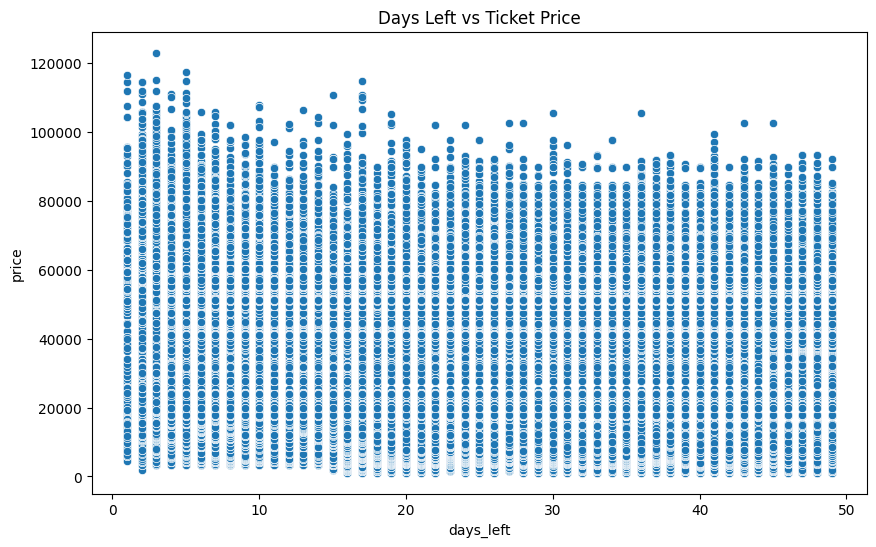

In [57]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='days_left', y='price', data=df)
plt.title('Days Left vs Ticket Price')
plt.show()

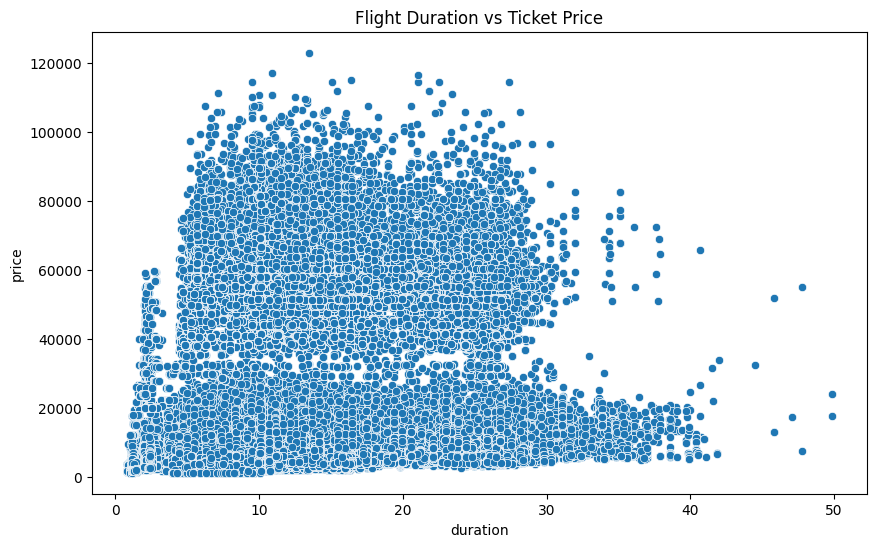

In [58]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='duration', y='price', data=df)
plt.title('Flight Duration vs Ticket Price')
plt.show()

In [59]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    # Convert the column to string type to ensure uniformity before encoding
    df_encoded[col] = df_encoded[col].astype(str)
    df_encoded[col] = le.fit_transform(df_encoded[col])

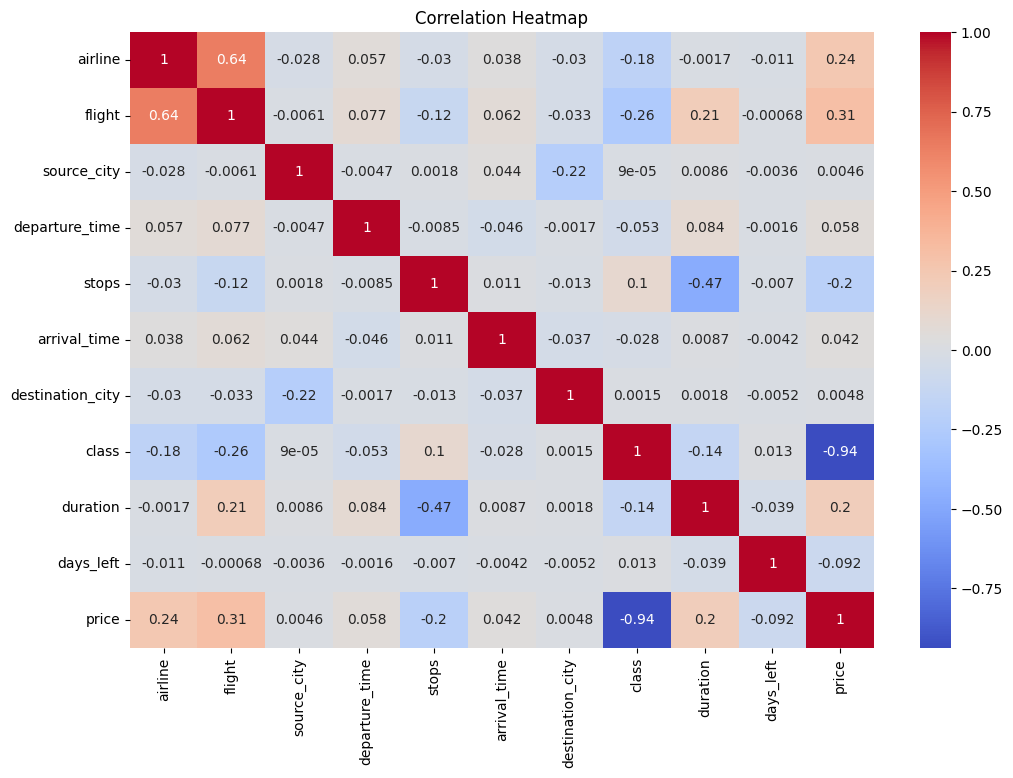

In [60]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [61]:
economy = df[df['class'] == 'Economy']['price']
business = df[df['class'] == 'Business']['price']

# Independent t-test

t_stat, p_value = stats.ttest_ind(economy, business)

print('T-statistic:', t_stat)
print('P-value:', p_value)

T-statistic: -1480.6808115131385
P-value: 0.0


In [62]:
if p_value < 0.05:
    print('Reject Null Hypothesis')
else:
    print('Fail to Reject Null Hypothesis')

Reject Null Hypothesis


In [63]:
airline_groups = [
    group['price'].values
    for name, group in df.groupby('airline')
]

f_stat, p_value = stats.f_oneway(*airline_groups)

print('F-statistic:', f_stat)
print('P-value:', p_value)

F-statistic: 17193.884085598915
P-value: 0.0


In [64]:
df_ml = df.copy()

label_encoders = {}

for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    # Convert the column to string type to ensure uniformity before encoding
    df_ml[col] = df_ml[col].astype(str)
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

In [65]:
X = df_ml.drop('price', axis=1)
y = df_ml['price']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [68]:
y_pred_lr = lr.predict(X_test)

In [69]:
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)

print('Linear Regression Results')
print('R2 Score:', r2_lr)
print('RMSE:', rmse_lr)
print('MAPE:', mape_lr)

Linear Regression Results
R2 Score: 0.9045500383121511
RMSE: 7014.094437902059
MAPE: 0.43352346306877987


In [70]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coefficients

,Feature,Coefficient
0,airline,907.749284
1,flight,0.345939
2,source_city,106.287667
3,departure_time,26.686602
4,stops,-3255.495339
5,arrival_time,187.385709
6,destination_city,120.576763
7,class,-44502.203378
8,duration,88.458809
9,days_left,-131.650487


In [71]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [72]:
y_pred_rf = rf.predict(X_test)

In [73]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

print('Random Forest Results')
print('R2 Score:', r2_rf)
print('RMSE:', rmse_rf)
print('MAPE:', mape_rf)

Random Forest Results
R2 Score: 0.9898583300290323
RMSE: 2286.3276394446
MAPE: 0.05781288822348273


In [74]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
7,class,0.879694
8,duration,0.047851
1,flight,0.029586
9,days_left,0.018125
6,destination_city,0.009825
2,source_city,0.006503
5,arrival_time,0.002895
3,departure_time,0.002454
4,stops,0.002086
0,airline,0.000980


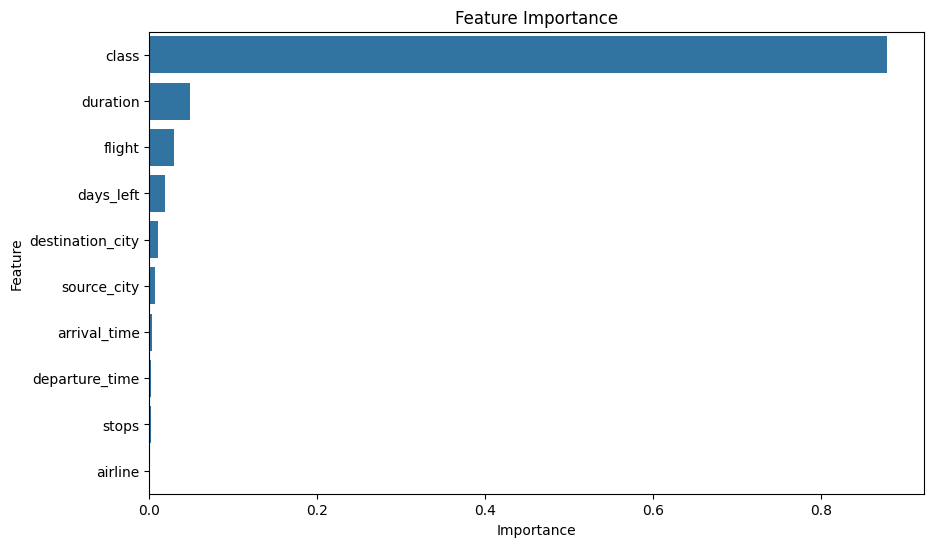

In [75]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title('Feature Importance')
plt.show()

In [76]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [r2_lr, r2_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'MAPE': [mape_lr, mape_rf]
})

results

,Model,R2 Score,RMSE,MAPE
0,Linear Regression,0.904550,7014.094438,0.433523
1,Random Forest,0.989858,2286.327639,0.057813


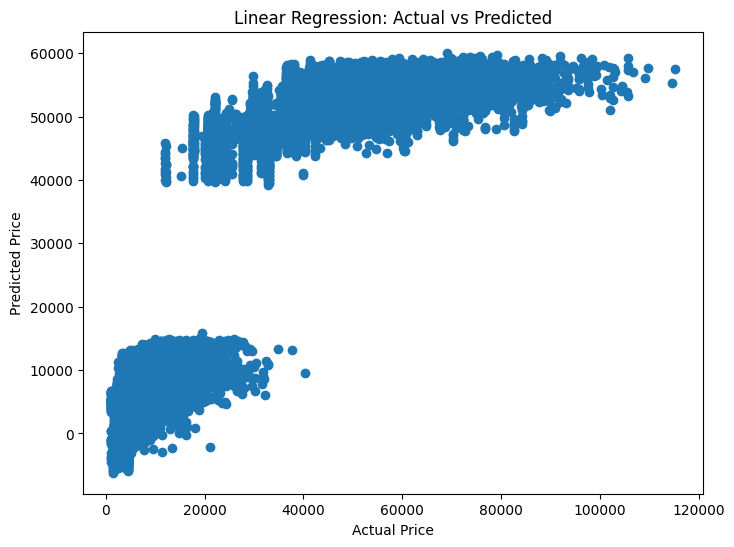

In [77]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

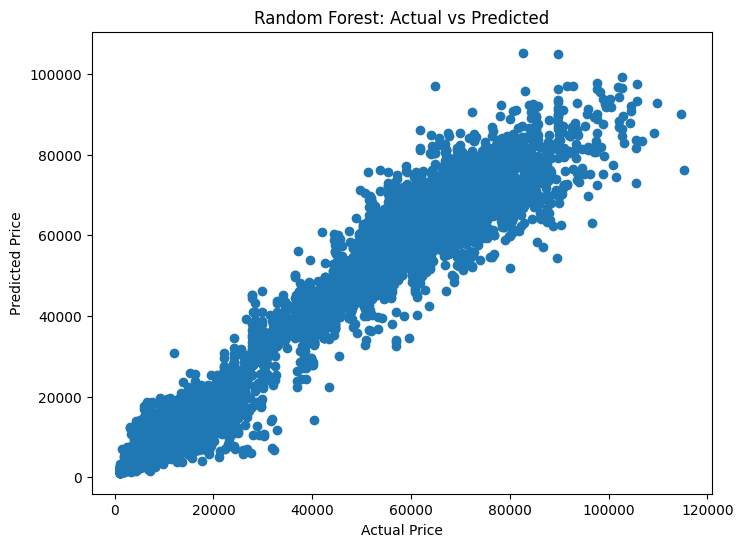

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted')
plt.show()